In [80]:
!pip install wordcloud

In [81]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report   
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [82]:
df

,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [83]:
df=pd.read_csv('spam.csv', encoding='latin-1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5572 non-null   object
 1   features    5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [84]:
df.describe(include='all')

,label,features,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [85]:
df=df[['label','features']]
df.columns=['label','text']
df.dropna(inplace=True)

In [86]:
le=LabelEncoder()
df['label_num']=le.fit_transform(df['label'])

In [87]:
X=df['text']
y=df['label_num']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test

3245    Funny fact Nobody teaches volcanoes 2 erupt, t...
944     I sent my scores to sophas and i had to do sec...
1044    We know someone who you know that fancies you....
2484    Only if you promise your getting out as SOON a...
812     Congratulations ur awarded either å£500 of CD ...
                              ...                        
4264     &lt;DECIMAL&gt; m but its not a common car he...
2439    Rightio. 11.48 it is then. Well arent we all u...
5556    Yes i have. So that's why u texted. Pshew...mi...
4205                               Get the door, I'm here
4293    Kit Strip - you have been billed 150p. Netcoll...
Name: text, Length: 1115, dtype: object

In [89]:
vectorizer = CountVectorizer()
X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)
X_test_vec


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13941 stored elements and shape (1115, 7735)>

In [90]:
model=MultinomialNB()
model.fit(X_train_vec,y_train)
y_pred=model.predict(X_test_vec)

In [103]:
y_pred

array([0, 0, 1, ..., 0, 0, 1], shape=(1115,))

In [91]:
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('Accuracy:',accuracy)
print('Classification_report:',report)

Accuracy: 0.9838565022421525
Classification_report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [97]:
spam_text = df[df['label'] == 'spam']['text']
ham_text = df[df['label'] == 'ham']['text']

Text(0.5, 1.0, 'Word Cloud for Spam Messages')

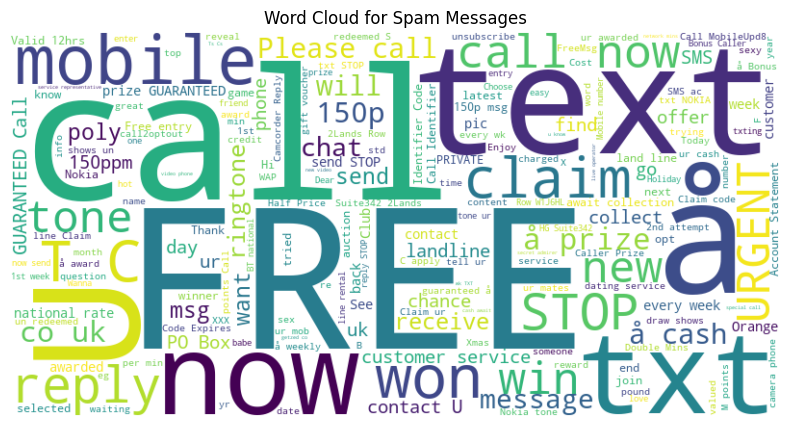

In [104]:
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text.str.cat(sep=' '))
plt.figure(figsize=(10, 5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Spam Messages')


Text(0.5, 1.0, 'Word Cloud for Ham Messages')

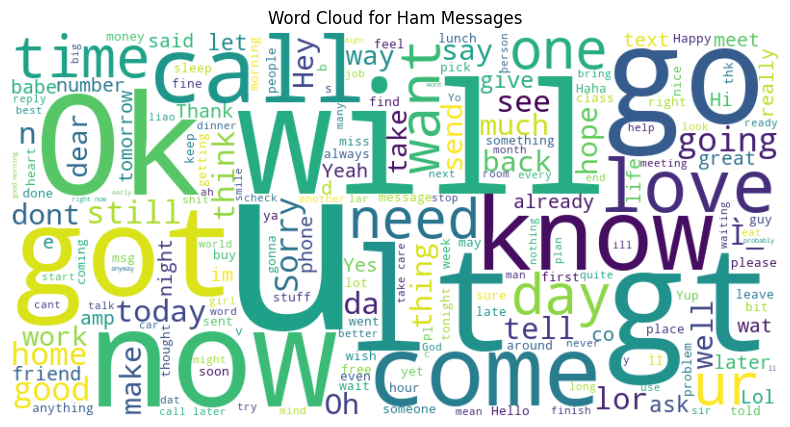

In [105]:
ham_wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text.str.cat(sep=' '))
plt.figure(figsize=(10, 5))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Ham Messages')
